In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np

In [2]:
path = r"C:\code\2526-LTXLDL-Project-1.5\processed"

In [56]:

df_daily = pd.read_csv(os.path.join(path, 'kpi_daily_2023.csv'))
df_weekly = pd.read_csv(os.path.join(path, 'kpi_weekly_2023.csv'))
df_monthly = pd.read_csv(os.path.join(path, 'kpi_monthly_2023.csv'))
df_PU = pd.read_csv(os.path.join(path, 'kpi_PU_2023.csv'))
df_DO = pd.read_csv(os.path.join(path, 'kpi_DO_2023.csv'))

<h2>Biểu đồ mối liên hệ giữa số chuyến xe và tốc độ trung bình<h2>

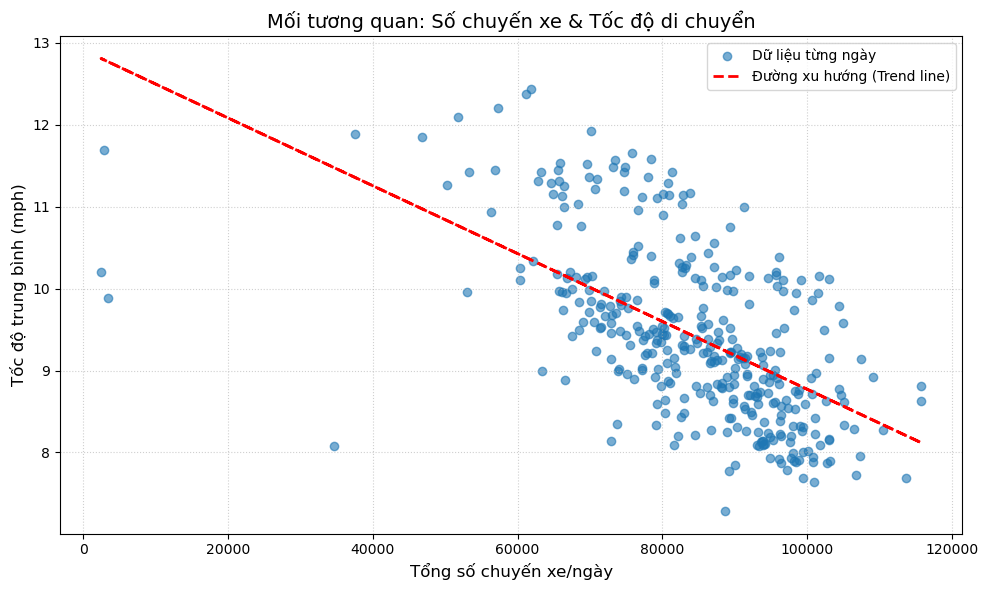

In [50]:
df = df_daily.dropna(subset=['total_trips', 'median_speed_mph'])
df['pickup_date'] = pd.to_datetime(df['pickup_date'])

# Vẽ biểu đồ
x = df["total_trips"]
y = df["median_speed_mph"]

plt.figure(figsize=(10,6))

# Vẽ các điểm 
plt.scatter(x, y, color='#1f77b4', alpha=0.6, label="Dữ liệu từng ngày")

# Vẽ đường xu hướng (Trend line)
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='red', linewidth=2, linestyle='--', label="Đường xu hướng (Trend line)")

plt.title("Mối tương quan: Số chuyến xe & Tốc độ di chuyển", fontsize=14)
plt.xlabel("Tổng số chuyến xe/ngày", fontsize=12)
plt.ylabel("Tốc độ trung bình (mph)", fontsize=12)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

<h2>Biểu đồ thời gian di chuyển trong tuần<h2>

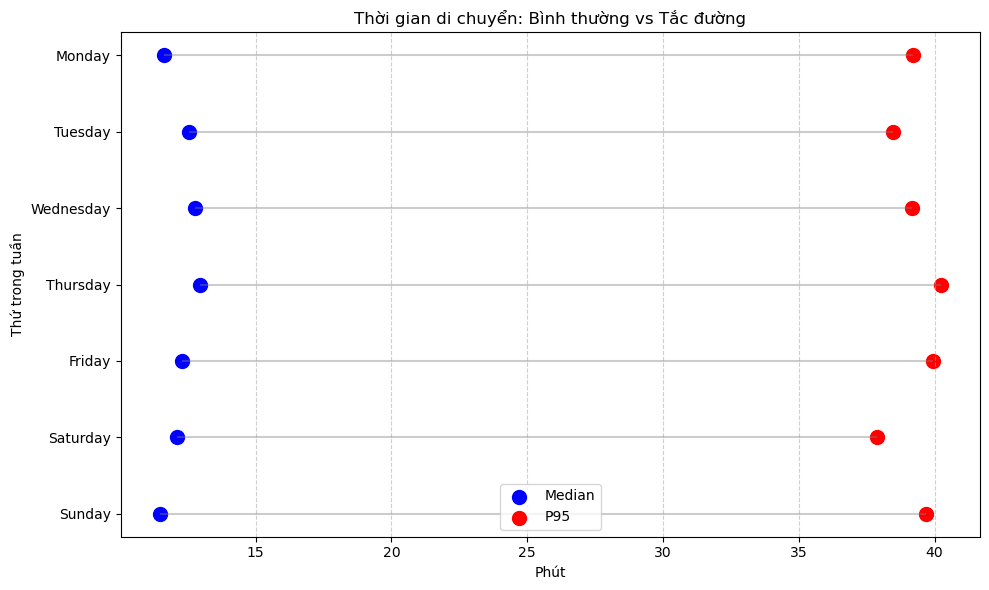

In [47]:
plt.figure(figsize=(10,6))
plt.hlines(df_weekly['pickup_dow'], df_weekly['median_duration_minutes'], df_weekly['p95_duration_minutes'], color='grey', alpha=0.4)
plt.scatter(df_weekly['median_duration_minutes'], df_weekly['pickup_dow'], color='blue', s=100, label='Median')
plt.scatter(df_weekly['p95_duration_minutes'], df_weekly['pickup_dow'], color='red', s=100, label='P95')

plt.title('Thời gian di chuyển: Bình thường vs Tắc đường')
plt.xlabel('Phút')
plt.ylabel('Thứ trong tuần')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

<h2>Biểu đồ tỉ trọng số chuyến theo tháng <h2>

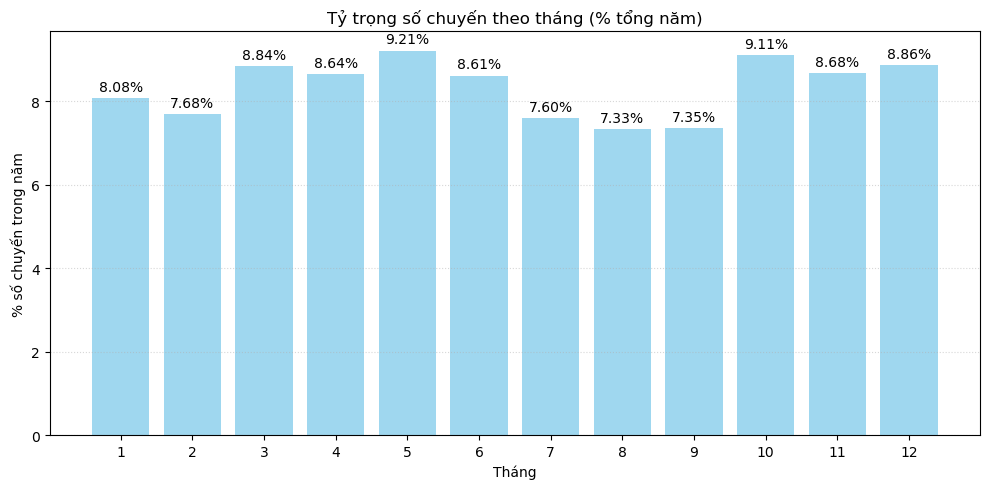

In [ ]:
df = df_monthly.reset_index()


plt.figure(figsize=(10,5))
bars = plt.bar(df_monthly["pickup_month"], df_monthly["percent_of_annual_trips"], color="skyblue", alpha=0.8)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.1, f"{height:.2f}%", ha='center', va='bottom', fontsize=10)

plt.title("Tỷ trọng số chuyến theo tháng (% tổng năm)")
plt.xlabel("Tháng")
plt.ylabel("% số chuyến trong năm")
plt.xticks(df["pickup_month"])
plt.grid(axis="y", linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

<h2>Biểu đồ top 20 địa điểm đón nhiều nhất<h2>

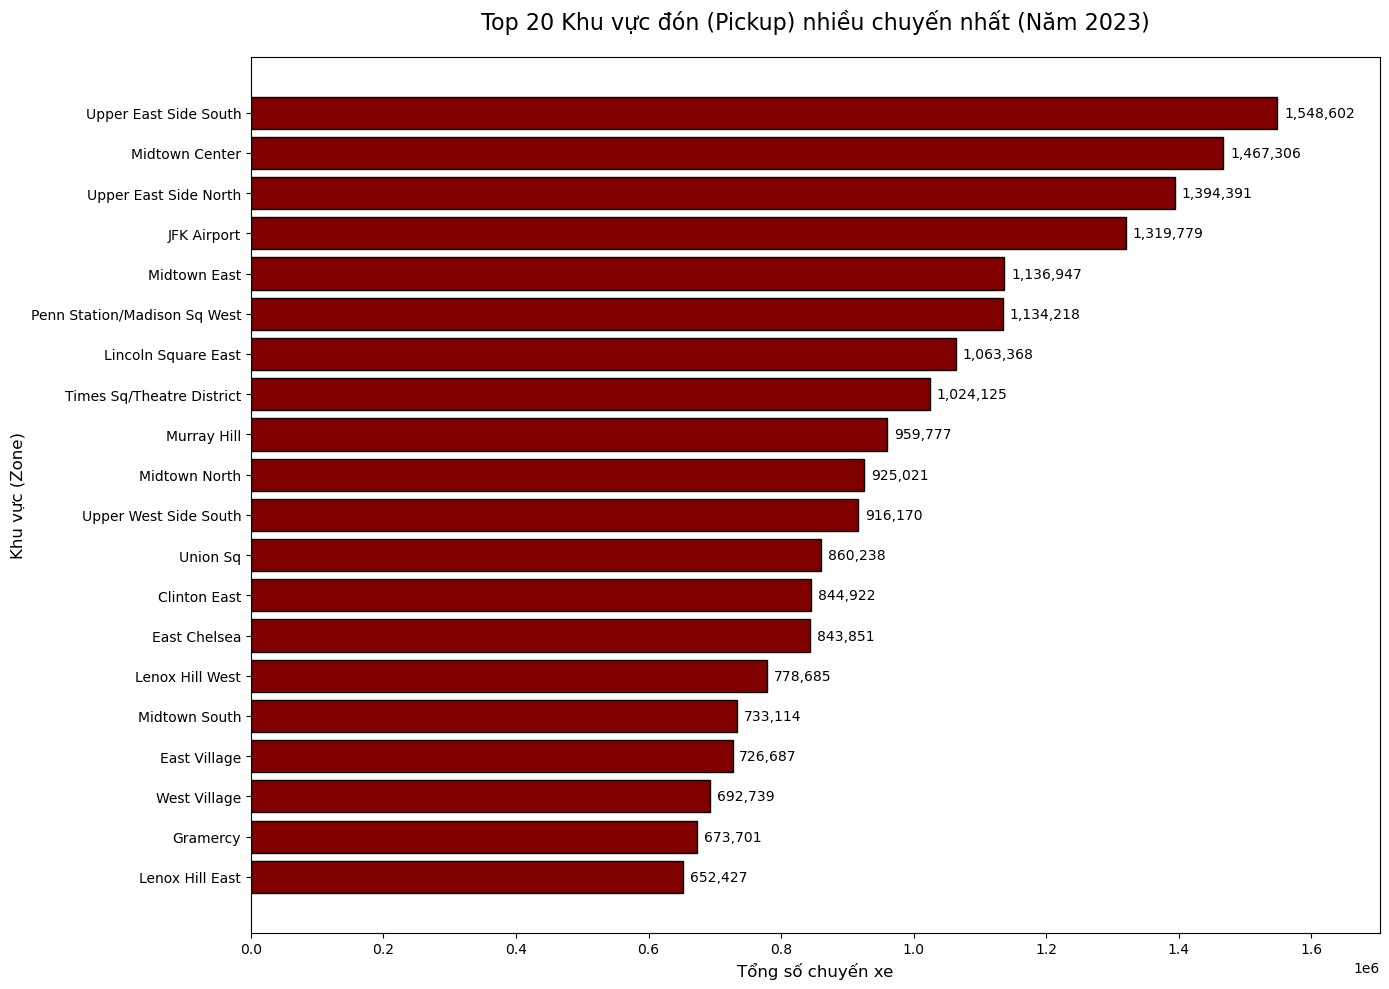

In [46]:
top_20 = df_PU.sort_values(by='total_trips', ascending=False).head(20)
top_20 = top_20.sort_values(by='total_trips', ascending=True)

plt.figure(figsize=(14, 10)) 

bars = plt.barh(top_20['PU_Zone'], top_20['total_trips'], color='maroon', edgecolor='black')

# 5. Thêm số liệu 
for bar in bars:
    width = bar.get_width()
    label = f'{int(width):,}' 
    plt.text(width + 10000, 
             bar.get_y() + bar.get_height()/2, 
             label, 
             va='center', fontsize=10, color='black')

plt.title('Top 20 Khu vực đón (Pickup) nhiều chuyến nhất (Năm 2023)', fontsize=16, pad=20)
plt.xlabel('Tổng số chuyến xe', fontsize=12)
plt.ylabel('Khu vực (Zone)', fontsize=12)

plt.xlim(0, top_20['total_trips'].max() * 1.1) 


plt.tight_layout()
plt.show()

<h2>Top 20 khu vực đến nhiều nhất<h2>

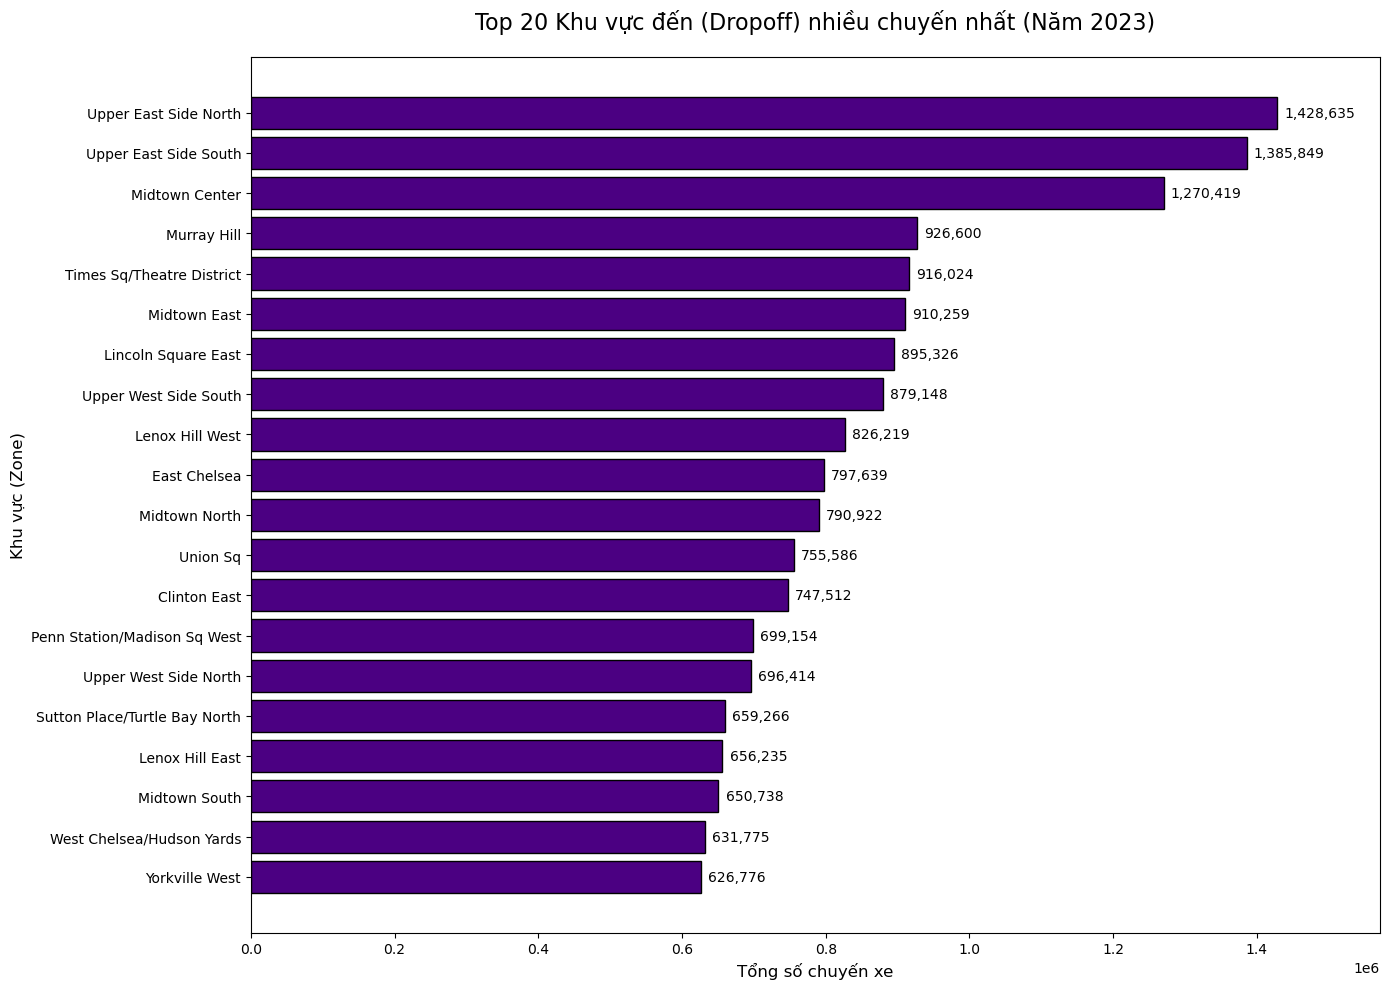

In [54]:
top_20 = df_DO.sort_values(by='total_trips', ascending=False).head(20)
top_20 = top_20.sort_values(by='total_trips', ascending=True)

plt.figure(figsize=(14, 10)) 

bars = plt.barh(top_20['DO_Zone'], top_20['total_trips'], color='#4b0082', edgecolor='black')

# 5. Thêm số liệu 
for bar in bars:
    width = bar.get_width()
    label = f'{int(width):,}' 
    plt.text(width + 10000, 
             bar.get_y() + bar.get_height()/2, 
             label, 
             va='center', fontsize=10, color='black')

plt.title('Top 20 Khu vực đến (Dropoff) nhiều chuyến nhất (Năm 2023)', fontsize=16, pad=20)
plt.xlabel('Tổng số chuyến xe', fontsize=12)
plt.ylabel('Khu vực (Zone)', fontsize=12)

plt.xlim(0, top_20['total_trips'].max() * 1.1) 


plt.tight_layout()
plt.show()